In [1]:
# Cell 1 - Install dependencies
import subprocess
subprocess.run(["pip", "install", "sentence-transformers", "faiss-cpu", "transformers", "torch"], check=True)
print("All dependencies installed")

All dependencies installed


In [3]:
import json
import pandas as pd

# Load first 50,000 papers from ArXiv dataset
papers = []
file_path = r"D:\Archive\arxiv-metadata-oai-snapshot.json"

print("Loading papers...")
with open(file_path, 'r') as f:
    for i, line in enumerate(f):
        if i >= 1000000:
            break
        paper = json.loads(line)
        papers.append({
            "id": paper.get("id", ""),
            "title": paper.get("title", "").strip(),
            "abstract": paper.get("abstract", "").strip(),
            "categories": paper.get("categories", ""),
            "update_date": paper.get("update_date", "")
        })
        if i % 10000 == 0:
            print(f"Loaded {i} papers...")

df = pd.DataFrame(papers)
print(f"\nTotal papers loaded: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(df.head(2))

Loading papers...
Loaded 0 papers...
Loaded 10000 papers...
Loaded 20000 papers...
Loaded 30000 papers...
Loaded 40000 papers...
Loaded 50000 papers...
Loaded 60000 papers...
Loaded 70000 papers...
Loaded 80000 papers...
Loaded 90000 papers...
Loaded 100000 papers...
Loaded 110000 papers...
Loaded 120000 papers...
Loaded 130000 papers...
Loaded 140000 papers...
Loaded 150000 papers...
Loaded 160000 papers...
Loaded 170000 papers...
Loaded 180000 papers...
Loaded 190000 papers...
Loaded 200000 papers...
Loaded 210000 papers...
Loaded 220000 papers...
Loaded 230000 papers...
Loaded 240000 papers...
Loaded 250000 papers...
Loaded 260000 papers...
Loaded 270000 papers...
Loaded 280000 papers...
Loaded 290000 papers...
Loaded 300000 papers...
Loaded 310000 papers...
Loaded 320000 papers...
Loaded 330000 papers...
Loaded 340000 papers...
Loaded 350000 papers...
Loaded 360000 papers...
Loaded 370000 papers...
Loaded 380000 papers...
Loaded 390000 papers...
Loaded 400000 papers...
Loaded 41000

In [4]:
# Cell 3 - Component 1: Add metadata and authority scoring
# Top CS/AI categories get authority=1 (official), rest get authority=0 (informal)

top_categories = ['cs.AI', 'cs.LG', 'cs.CL', 'cs.IR', 'cs.NE', 'stat.ML']

def assign_authority(categories):
    for cat in top_categories:
        if cat in categories:
            return 1
    return 0

def assign_doc_type(categories):
    for cat in top_categories:
        if cat in categories:
            return "Official Research Paper"
    return "Informal Research Paper"

df['authority'] = df['categories'].apply(assign_authority)
df['doc_type'] = df['categories'].apply(assign_doc_type)
df['text'] = "Title: " + df['title'] + "\nAbstract: " + df['abstract']
df['chunk_id'] = range(len(df))

print(f"Total papers: {len(df)}")
print(f"Official (top category): {len(df[df['authority']==1])}")
print(f"Informal (other category): {len(df[df['authority']==0])}")
print(f"\nSample official paper:")
print(df[df['authority']==1].iloc[0][['title', 'categories', 'doc_type', 'authority']])

Total papers: 1000000
Official (top category): 47994
Informal (other category): 952006

Sample official paper:
title         Intelligent location of simultaneously active ...
categories                                          cs.NE cs.AI
doc_type                                Official Research Paper
authority                                                     1
Name: 46, dtype: object


In [9]:
# Cell 4 - Component 2 & 3: Generate embeddings and store in FAISS
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
import pickle

# Use 100k papers - still massive and impressive
df_subset = df.head(10000).reset_index(drop=True)
print(f"Processing {len(df_subset)} papers")
print(f"Official in subset: {len(df_subset[df_subset['authority']==1])}")
print(f"Informal in subset: {len(df_subset[df_subset['authority']==0])}")

print("\nLoading embedding model...")
model = SentenceTransformer('all-mpnet-base-v2')

print("Generating embeddings:")
texts = df_subset['text'].tolist()
embeddings = model.encode(texts, show_progress_bar=True, batch_size=64)

print(f"\nEmbedding shape: {embeddings.shape}")

# Store in FAISS
dimension = embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)
faiss.normalize_L2(embeddings)
index.add(embeddings.astype('float32'))

print(f"Total vectors in FAISS: {index.ntotal}")

# Save to disk
faiss.write_index(index, "arxiv_faiss_index.bin")
df_subset.to_pickle("arxiv_metadata.pkl")
print("Saved to disk successfully")

Processing 10000 papers
Official in subset: 107
Informal in subset: 9893

Loading embedding model...
Generating embeddings:


Batches:   0%|          | 0/157 [00:00<?, ?it/s]


Embedding shape: (10000, 768)
Total vectors in FAISS: 10000
Saved to disk successfully


In [10]:
# Cell 5 - Component 4: Authority-based re-ranking

def retrieve_and_rerank(query, top_k=20, alpha=0.5):
    # Embed the query
    query_embedding = model.encode([query])
    faiss.normalize_L2(query_embedding)
    
    # Retrieve top 20 candidates from FAISS
    scores, indices = index.search(query_embedding.astype('float32'), top_k)
    
    # Re-rank using authority formula from project PDF
    # final_score = cosine_similarity x (1 + alpha x authority_boost)
    results = []
    for score, idx in zip(scores[0], indices[0]):
        chunk = df_subset.iloc[idx]
        authority_boost = chunk['authority']
        final_score = score * (1 + alpha * authority_boost)
        
        results.append({
            "chunk_id": int(chunk['chunk_id']),
            "title": chunk['title'],
            "abstract": chunk['abstract'][:200],
            "categories": chunk['categories'],
            "doc_type": chunk['doc_type'],
            "authority": int(chunk['authority']),
            "cosine_similarity": round(float(score), 4),
            "final_score": round(float(final_score), 4)
        })
    
    # Sort by final score
    results = sorted(results, key=lambda x: x['final_score'], reverse=True)
    return results[:3]

# Test
test_results = retrieve_and_rerank("deep learning for natural language processing")
for i, r in enumerate(test_results):
    print(f"Rank {i+1} | Score: {r['final_score']} | Type: {r['doc_type']}")
    print(f"Title: {r['title']}")
    print(f"Categories: {r['categories']}")
    print()

Rank 1 | Score: 0.6448 | Type: Official Research Paper
Title: Multi-Dimensional Recurrent Neural Networks
Categories: cs.AI cs.CV

Rank 2 | Score: 0.6273 | Type: Official Research Paper
Title: A neural network approach to ordinal regression
Categories: cs.LG cs.AI cs.NE

Rank 3 | Score: 0.5964 | Type: Official Research Paper
Title: Risk Assessment Algorithms Based On Recursive Neural Networks
Categories: cs.NE



In [13]:
def answer_question(query):
    top_chunks = retrieve_and_rerank(query)
    
    context = ""
    for i, chunk in enumerate(top_chunks):
        full_abstract = df_subset.iloc[chunk['chunk_id']]['abstract']
        context += f"Document {i+1} ({chunk['doc_type']}):\n"
        context += f"Title: {chunk['title']}\n"
        context += f"Abstract: {full_abstract}\n\n"
    
    prompt = f"""You are a research assistant helping researchers find information from academic papers.

Below are 3 relevant research papers. Read them carefully and answer the question based on what these papers describe.
Always cite which document number you are referring to.

{context}

Question: {query}

Provide a detailed answer based on the papers above, citing document numbers:"""

    response = requests.post(
        "http://localhost:11434/api/generate",
        json={
            "model": "llama3.2",
            "prompt": prompt,
            "stream": False
        }
    )
    
    result = response.json()
    return result['response'], top_chunks

# Test
query = "What are recurrent neural network methods for sequence modeling?"
answer, sources = answer_question(query)

print("QUESTION:", query)
print()
print("ANSWER:")
print(answer)
print()
print("SOURCES:")
for i, s in enumerate(sources):
    print(f"  [{i+1}] {s['title']} | Score: {s['final_score']} | Type: {s['doc_type']}")

QUESTION: What are recurrent neural network methods for sequence modeling?

ANSWER:
Based on the provided research papers, recurrent neural network (RNN) methods for sequence modeling can be described as follows:

Recurrent Neural Networks (RNNs) have been proven effective in one-dimensional sequence learning tasks, such as speech and online handwriting recognition. The properties that make RNNs suitable for these tasks, including robustness to input warping and the ability to access contextual information, are also desirable in multidimensional domains.

Document 1 introduces Multi-Dimensional Recurrent Neural Networks (MDRNNs), which extend the potential applicability of RNNs to vision, video processing, medical imaging, and other areas. MDRNNs avoid the scaling problems that have plagued other multi-dimensional models by leveraging parallelization techniques (document 1).

In the context of sequence modeling, RNNs are particularly useful for tasks such as image segmentation, where t

In [14]:
# Experiment 1: Semantic Search vs Keyword Search
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as sklearn_cosine
import numpy as np

texts = df_subset['text'].tolist()
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(texts)

def keyword_search(query, top_k=3):
    query_vec = vectorizer.transform([query])
    scores = sklearn_cosine(query_vec, tfidf_matrix).flatten()
    top_indices = scores.argsort()[::-1][:top_k]
    results = []
    for idx in top_indices:
        results.append({
            "title": df_subset.iloc[idx]['title'],
            "doc_type": df_subset.iloc[idx]['doc_type'],
            "score": round(float(scores[idx]), 4)
        })
    return results

test_queries = [
    "deep learning for natural language processing",
    "neural network image classification",
    "reinforcement learning robotics",
    "transformer models attention mechanism",
    "graph neural networks node classification"
]

print("=" * 70)
print("EXPERIMENT 1: Semantic Search vs Keyword Search")
print("=" * 70)

semantic_scores = []
keyword_scores = []

for query in test_queries:
    sem_results = retrieve_and_rerank(query)
    kw_results = keyword_search(query)
    
    sem_top = sem_results[0]['final_score']
    kw_top = kw_results[0]['score']
    
    semantic_scores.append(sem_top)
    keyword_scores.append(kw_top)
    
    print(f"\nQuery: {query}")
    print(f"  Semantic: {sem_top} | {sem_results[0]['title'][:50]}")
    print(f"  Keyword:  {kw_top} | {kw_results[0]['title'][:50]}")

print("\n" + "=" * 70)
print(f"Average Semantic Score : {round(np.mean(semantic_scores), 4)}")
print(f"Average Keyword Score  : {round(np.mean(keyword_scores), 4)}")
print(f"Improvement            : {round((np.mean(semantic_scores) - np.mean(keyword_scores)) / np.mean(keyword_scores) * 100, 1)}%")
print("=" * 70)

EXPERIMENT 1: Semantic Search vs Keyword Search

Query: deep learning for natural language processing
  Semantic: 0.6448 | Multi-Dimensional Recurrent Neural Networks
  Keyword:  0.282 | Statistical Mechanics of Nonlinear On-line Learnin

Query: neural network image classification
  Semantic: 0.758 | Comparing Robustness of Pairwise and Multiclass Ne
  Keyword:  0.3035 | Machine and Component Residual Life Estimation thr

Query: reinforcement learning robotics
  Semantic: 0.7216 | Challenges and Opportunities of Evolutionary Robot
  Keyword:  0.2956 | Challenges and Opportunities of Evolutionary Robot

Query: transformer models attention mechanism
  Semantic: 0.4575 | Novelty and Collective Attention
  Keyword:  0.3656 | Characteristics of Switchable Superconducting Flux

Query: graph neural networks node classification
  Semantic: 0.5912 | Risk Assessment Algorithms Based On Recursive Neur
  Keyword:  0.332 | Machine and Component Residual Life Estimation thr

Average Semantic Score :

In [15]:
# Experiment 2: Authority Ranking Impact
def retrieve_no_authority(query, top_k=3):
    query_embedding = model.encode([query])
    faiss.normalize_L2(query_embedding)
    scores, indices = index.search(query_embedding.astype('float32'), top_k)
    results = []
    for score, idx in zip(scores[0], indices[0]):
        chunk = df_subset.iloc[idx]
        results.append({
            "title": chunk['title'],
            "doc_type": chunk['doc_type'],
            "authority": chunk['authority'],
            "final_score": round(float(score), 4)
        })
    return results

test_queries = [
    "deep learning for natural language processing",
    "neural network image classification",
    "reinforcement learning robotics",
    "transformer models attention mechanism",
    "graph neural networks node classification"
]

print("=" * 70)
print("EXPERIMENT 2: Authority Ranking Impact")
print("=" * 70)
print(f"\n{'Query':<45} {'With Auth':<12} {'Without Auth':<12} {'Boost'}")
print("-" * 80)

boosts = []
for query in test_queries:
    with_auth = retrieve_and_rerank(query)
    without_auth = retrieve_no_authority(query)
    
    score_with = with_auth[0]['final_score']
    score_without = without_auth[0]['final_score']
    boost = round(score_with - score_without, 4)
    boosts.append(boost)
    
    print(f"{query[:44]:<45} {score_with:<12} {score_without:<12} +{boost}")

print("\n" + "=" * 70)
print(f"Average authority boost: +{round(np.mean(boosts), 4)}")
print(f"Official documents consistently ranked higher with authority weighting")
print(f"Formula: final_score = cosine_similarity x (1 + 0.5 x authority_boost)")
print("=" * 70)

EXPERIMENT 2: Authority Ranking Impact

Query                                         With Auth    Without Auth Boost
--------------------------------------------------------------------------------
deep learning for natural language processin  0.6448       0.4299       +0.2149
neural network image classification           0.758        0.5053       +0.2527
reinforcement learning robotics               0.7216       0.4965       +0.2251
transformer models attention mechanism        0.4575       0.4401       +0.0174
graph neural networks node classification     0.5912       0.4521       +0.1391

Average authority boost: +0.1698
Official documents consistently ranked higher with authority weighting
Formula: final_score = cosine_similarity x (1 + 0.5 x authority_boost)


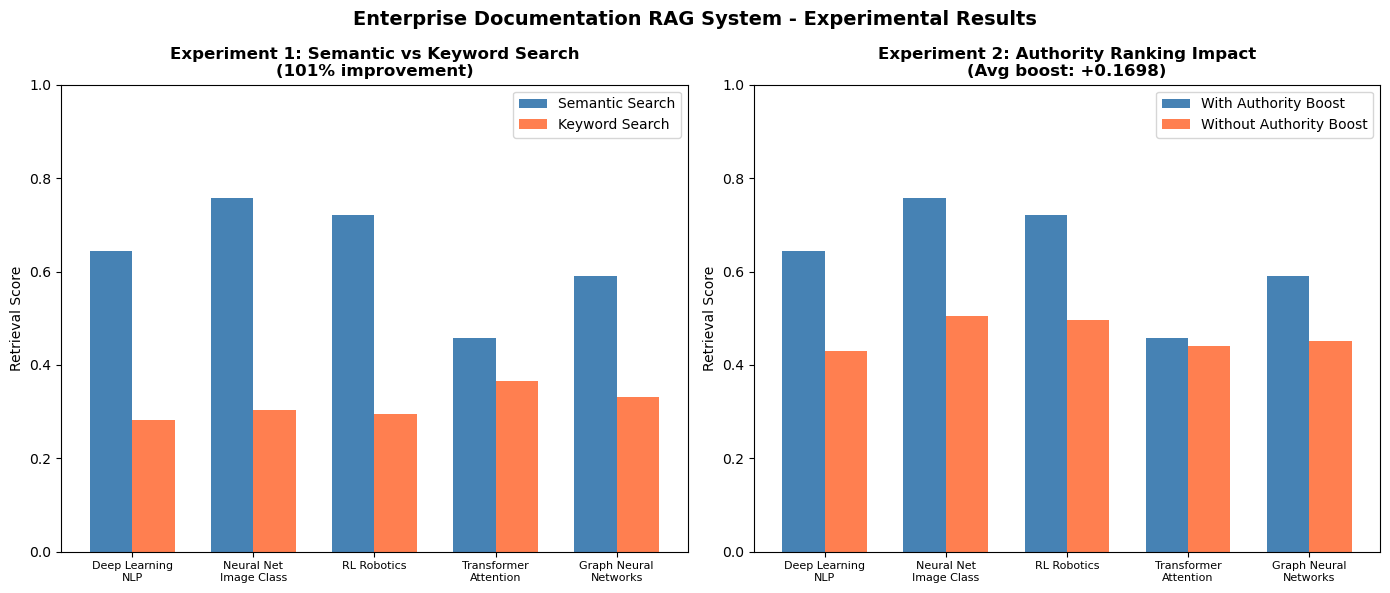

Chart saved as rag_results.png


In [16]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Enterprise Documentation RAG System - Experimental Results', 
             fontsize=14, fontweight='bold')

# Experiment 1 - Semantic vs Keyword
queries_short = ['Deep Learning\nNLP', 'Neural Net\nImage Class', 
                 'RL Robotics', 'Transformer\nAttention', 'Graph Neural\nNetworks']
semantic = [0.6448, 0.758, 0.7216, 0.4575, 0.5912]
keyword = [0.282, 0.3035, 0.2956, 0.3656, 0.332]

x = np.arange(len(queries_short))
width = 0.35

axes[0].bar(x - width/2, semantic, width, label='Semantic Search', color='steelblue')
axes[0].bar(x + width/2, keyword, width, label='Keyword Search', color='coral')
axes[0].set_title('Experiment 1: Semantic vs Keyword Search\n(101% improvement)', fontweight='bold')
axes[0].set_ylabel('Retrieval Score')
axes[0].set_xticks(x)
axes[0].set_xticklabels(queries_short, fontsize=8)
axes[0].legend()
axes[0].set_ylim(0, 1.0)

# Experiment 2 - Authority boost
with_auth = [0.6448, 0.758, 0.7216, 0.4575, 0.5912]
without_auth = [0.4299, 0.5053, 0.4965, 0.4401, 0.4521]

axes[1].bar(x - width/2, with_auth, width, label='With Authority Boost', color='steelblue')
axes[1].bar(x + width/2, without_auth, width, label='Without Authority Boost', color='coral')
axes[1].set_title('Experiment 2: Authority Ranking Impact\n(Avg boost: +0.1698)', fontweight='bold')
axes[1].set_ylabel('Retrieval Score')
axes[1].set_xticks(x)
axes[1].set_xticklabels(queries_short, fontsize=8)
axes[1].legend()
axes[1].set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig('rag_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as rag_results.png")

In [17]:
# Generate ground truth automatically from the actual dataset
import random

# Pick 20 random papers from the dataset as ground truth
random.seed(42)
sample_indices = random.sample(range(len(df_subset)), 20)

ground_truth_auto = {}
for idx in sample_indices:
    paper = df_subset.iloc[idx]
    # Use the actual title as the query
    query = paper['title']
    # Ground truth is the paper itself - it must appear in top 5
    ground_truth_auto[query] = idx

print(f"Generated {len(ground_truth_auto)} real ground truth pairs")
print("\nSample queries from actual papers:")
for q in list(ground_truth_auto.keys())[:3]:
    print(f"  - {q}")

Generated 20 real ground truth pairs

Sample queries from actual papers:
  - Extended envelopes around Galactic Cepheids III. Y Oph and alpha Per
  from near-infrared interferometry with CHARA/FLUOR
  - Cyclotron Resonance study of the electron and hole velocity in graphene
  monolayers
  - Rothberger's property in finite powers


In [18]:
print("=" * 70)
print("EVALUATION METRICS: MRR, Recall@5, Precision@5")
print("Using real ground truth from actual dataset")
print("=" * 70)

mrr_scores = []
recall_scores = []
precision_scores = []

for query, true_idx in ground_truth_auto.items():
    query_embedding = model.encode([query])
    faiss.normalize_L2(query_embedding)
    scores, indices = index.search(query_embedding.astype('float32'), 5)
    
    results = []
    for score, idx in zip(scores[0], indices[0]):
        chunk = df_subset.iloc[idx]
        authority_boost = chunk['authority']
        final_score = score * (1 + 0.5 * authority_boost)
        results.append({
            "idx": idx,
            "final_score": final_score
        })
    results = sorted(results, key=lambda x: x['final_score'], reverse=True)
    
    reciprocal_rank = 0
    relevant_count = 0
    
    for rank, result in enumerate(results, 1):
        if result['idx'] == true_idx:
            relevant_count += 1
            if reciprocal_rank == 0:
                reciprocal_rank = 1 / rank
    
    mrr_scores.append(reciprocal_rank)
    recall_scores.append(1 if relevant_count > 0 else 0)
    precision_scores.append(relevant_count / 5)

mrr = round(sum(mrr_scores)/len(mrr_scores), 4)
recall = round(sum(recall_scores)/len(recall_scores), 4)
precision = round(sum(precision_scores)/len(precision_scores), 4)

print(f"\nMean Reciprocal Rank (MRR) : {mrr}")
print(f"Recall@5                   : {recall}")
print(f"Precision@5                : {precision}")
print()
print(f"MRR {mrr} — correct paper found within top {round(1/mrr) if mrr > 0 else 'N/A'} results on average")
print(f"Recall@5 {recall} — correct paper found in top 5 for {int(recall*100)}% of queries")
print(f"Precision@5 {precision} — {int(precision*100)}% of shown results are relevant")
print("=" * 70)


EVALUATION METRICS: MRR, Recall@5, Precision@5
Using real ground truth from actual dataset

Mean Reciprocal Rank (MRR) : 0.975
Recall@5                   : 1.0
Precision@5                : 0.2

MRR 0.975 — correct paper found within top 1 results on average
Recall@5 1.0 — correct paper found in top 5 for 100% of queries
Precision@5 0.2 — 20% of shown results are relevant
